In [1]:
from tensorflow.python.framework.test_util import is_gpu_available

# Check if GPU is available for TensorFlow computations
gpu_available = is_gpu_available(cuda_only=False, min_cuda_compute_capability=None)

print("GPU available:", gpu_available)

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU available: True


In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.ndimage import gaussian_filter1d

In [3]:
def load_data(data_path, placement):
    data = []
    labels = []
    acc = []
    gyr = []
    mag = []
    for i in range(0,len(placement)-1, 3):
        acc.append(placement[i])
        gyr.append(placement[i+1])
        mag.append(placement[i+2])

    # print(acc)
    for folder in os.listdir(data_path):
        folder_path = os.path.join(data_path, folder)
        
        # Check if folder name can be converted to an integer, otherwise use a default label (-1)
        try:
            if "N" in folder:
                label = 0
            elif "BY" in folder:
                label = 1
            elif "FY" in folder:
                label = 2
            elif "SY" in folder:
                label = 3
            else:
                label = 0
        except ValueError:
            label = -1
        
        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            df = pd.read_csv(file_path)
            filtered_data = df.apply(lambda col: gaussian_filter1d(col, sigma=5), axis=0)
            features = []
            for sensor_columns in acc:
                
                acceleration_data = filtered_data[sensor_columns].values
                sx = acceleration_data[:, 0]
                sy = acceleration_data[:, 1]
                sz = acceleration_data[:, 2]
                # Sum of norm values
                Snorm = np.sqrt(sx**2 + sy**2 +sz**2)
                # thriaxial sensor
                features.append(sx)
                features.append(sy)
                features.append(sz)
                # # main features
                features.append(Snorm)

            for sensor_columns in gyr:
                
                Gyroscope_data = filtered_data[sensor_columns].values
                gsx = Gyroscope_data[:, 0]
                gsy = Gyroscope_data[:, 1]
                gsz = Gyroscope_data[:, 2]
                
                Snorm2 = np.sqrt(gsx**2 + gsy**2 + gsz**2)
                features.append(gsx)
                features.append(gsy)
                features.append(gsz)

                # # main features
                features.append(Snorm2)

            for sensor_columns in mag:
                
                Magnetic_data = filtered_data[sensor_columns].values
                msx = Magnetic_data[:, 0]
                msy = Magnetic_data[:, 1]
                msz = Magnetic_data[:, 2]
                features.append(msx)
                features.append(msy)
                features.append(msz)


                Snorm3 = np.sqrt(msx**2 + msy**2 + msz**2)
                features.append(Snorm3)

            # Convert features to a NumPy array
            features1 = np.array(features)
            features2 = np.transpose(features1, (1, 0))
            # print(features2.shape)
            data.append(features2)
            labels.append(label)
            
    return np.array(data), np.array(labels)

In [4]:
def window_labeling(Data, window_size, overlap_size, y):
    dataset = []
    labels = []

    for window, lab in zip(Data, y):

        for i in range(0, len(window) - window_size + 1, overlap_size):
            wind = window[i:i+window_size]
            dataset.append(wind)
            labels.append(lab)

    return np.array(dataset), np.array(labels)

In [ ]:
import numpy as np
from scipy.stats import kurtosis, skew

def time_domain_features(data):
    # Time-domain features
    Fmax = np.max(data, axis=1)
    Fmin = np.min(data, axis=1)
    FSD = np.std(data, axis=1)
    FAbSum = np.sum(np.abs(data), axis=1)
    FRMS = np.sqrt(np.mean(data ** 2, axis=1))
    # Fkurt = kurtosis(data, axis=1)
    # Fskew = skew(data, axis=1)
    FGMM = np.mean(data, axis=1)
    FDMM = Fmax - Fmin
    FMD = np.max(np.diff(data, axis=1), axis=1)
    
    return np.column_stack((Fmax, Fmin, FSD, FAbSum, FRMS, FGMM, FDMM, FMD)) # Fkurt, Fskew,

def frequency_domain_features(data):
    # Frequency-domain features
    fft_values = np.fft.fft(data, axis=1)
    fft_abs = np.abs(fft_values)
    fft_power = np.abs(fft_values) ** 2

    Fmax = np.max(fft_abs, axis=1)
    Fmin = np.min(fft_abs, axis=1)
    FSD = np.std(fft_abs, axis=1)
    FAbSum = np.sum(fft_abs, axis=1)
    FRMS = np.sqrt(np.mean(fft_power, axis=1))
    Fkurt = kurtosis(fft_abs, axis=1)
    Fskew = skew(fft_abs, axis=1)
    FGMM = np.mean(fft_abs, axis=1)
    FDMM = Fmax - Fmin
    FMD = np.max(np.diff(fft_abs, axis=1), axis=1)

    return np.column_stack((Fmax, Fmin, FSD, FAbSum, FRMS, Fkurt, Fskew, FGMM, FDMM, FMD))

In [6]:
from collections import Counter
from sklearn.preprocessing import  StandardScaler
from keras.utils import to_categorical
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,confusion_matrix,balanced_accuracy_score

def display_result(y_test , y_pred) :
    print('Accuracy score : ', accuracy_score(y_test , y_pred) )
    print('Precision score : ', precision_score(y_test , y_pred, average='weighted'))
    print('Recall score : ', recall_score(y_test , y_pred, average='weighted'))
    print('F1 score : ', f1_score(y_test , y_pred, average='weighted'))
    

def scaled_data(X_train, X_test, X_val):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_val_scaled = scaler.transform(X_val)
    return X_train_scaled, X_test_scaled , X_val_scaled


def convert_to_categorical (y_train, y_test, y_val) :
    print('--------------------------To Categorical ---------------------------')
    Y_train = to_categorical(y_train, 12)
    Y_test = to_categorical(y_test, 12)
    Y_val = to_categorical(y_val,12)
    
    print('Before    : ', y_train[0])
    print('After     : ',Y_train[0])
    class_count = len(Counter(y_val))
    return Y_train, Y_test, Y_val 

In [ ]:
# Multi-Class Classification without LabelEncoder (Manually Encoded Labels)

import os
import time
import random
from datetime import datetime

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             ConfusionMatrixDisplay)
from sklearn.svm import SVC

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# Define classifiers
classifiers = {
    'Support Vector Machine (SVM)': SVC(kernel='rbf', C=10, gamma='scale')
    # Add others here as needed
}

def performance_v1(X, y, acc_):
    # Define the number of classes based on the dataset
    num_classes = len(np.unique(y))
    # Step 1: Define class names based on the number of classes
    if num_classes == 2:
        target_names = ['Non_fall', 'Falls']
    elif num_classes == 3:
        target_names = ['BY', 'FY', 'SY']
    elif num_classes == 4:
        target_names = ['N', 'BY', 'FY', 'SY']
    else:
        target_names = ['N', 'BY', 'FY', 'SY', 'ADL']

    # Train-test split
    X_train, X_test, y_train_o, y_test_o = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

    # Standardization helps prevent features with large numeric ranges (e.g., 0–1000) from dominating features with smaller ranges (e.g., 0–1).
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # This block handles missing values (NaNs) in our dataset using a method called imputation.
    imputer = SimpleImputer(strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    X_train_np = X_train.astype(np.float32)
    X_test_np = X_test.astype(np.float32)
    y_train_np = y_train_o.astype(np.int32)
    y_test_np = y_test_o.astype(np.int32)

    # This line sets up a cross-validation strategy called StratifiedShuffleSplit from sklearn.model_selection. 
    # Split our dataset into training and validation sets.
    # Repeat this process n_splits times.
    # Ensure each split preserves the class distribution (i.e., stratified).
    skf = StratifiedShuffleSplit(n_splits=10, test_size=0.3, random_state=0)

    # Metric storage
    accuracies, precisions, recalls, f1_scores = [], [], [], []
    training_times, testing_times = [], []

    # Training and valuation stage with cross-valuation 10 times
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_np, y_train_np)):
        print(f"\n--- Fold {fold_idx + 1} ---")

        X_fold_train, X_fold_val = X_train_np[train_idx], X_train_np[val_idx]
        y_fold_train, y_fold_val = y_train_np[train_idx], y_train_np[val_idx]

        name, model = list(classifiers.items())[0]
        start_train = time.time()
        model.fit(X_fold_train, y_fold_train)
        end_train = time.time()
        training_times.append(end_train - start_train)
        y_pred = model.predict(X_fold_val)

        acc = accuracy_score(y_fold_val, y_pred)
        prec = precision_score(y_fold_val, y_pred, average='weighted', zero_division=1)
        rec = recall_score(y_fold_val, y_pred, average='weighted', zero_division=1)
        f1 = f1_score(y_fold_val, y_pred, average='weighted', zero_division=1)

        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)

        print(f'Classification Report (Fold {fold_idx + 1}):')
        fold_target_names = [str(target_names[i]) for i in np.unique(y_fold_val)]
        print(classification_report(y_fold_val, y_pred, target_names=fold_target_names))

    # Cross-validation results summary
    print(f"\n=== Cross-Validation Summary for {name} ===")
    print(f"Avg Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
    print(f"Avg Precision: {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
    print(f"Avg Recall: {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
    print(f"Avg F1 Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

    # Final test evaluation
    model.fit(X_train_np, y_train_np)
    start_test = time.time()
    y_test_pred = model.predict(X_test_np)
    end_test = time.time()
    testing_time = end_test - start_test
    testing_times.append(end_test - start_test)

    acc = accuracy_score(y_test_np, y_test_pred)
    prec = precision_score(y_test_np, y_test_pred, average='weighted')
    rec = recall_score(y_test_np, y_test_pred, average='weighted')
    f1 = f1_score(y_test_np, y_test_pred, average='weighted')

    print(f"\nTest Results for {name}:")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, Time: {testing_time:.2f}s")
    print(classification_report(y_test_np, y_test_pred, target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_test_np, y_test_pred)
    cm_normalized = confusion_matrix(y_test_np, y_test_pred, normalize='true')
    cm_percent = np.round(cm_normalized * 100, 2)

    plt.figure(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=target_names)
    disp.plot(cmap='viridis', xticks_rotation=45, values_format=".2f")
    plt.title(f"Confusion Matrix (%) - {name} (Test Data)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    
    return {
        'accuracies': accuracies,
        'precisions': precisions,
        'recalls': recalls,
        'f1_scores': f1_scores,
        'mean_accuracy': np.mean(accuracies),
        'std_dev': np.std(accuracies),
        'training_times': training_times,
        'testing_times': testing_times,
        'places': acc  # sensor location index value
    }


Index of experiment: 0
Experiment #: [2]
(2871, 216)

--- Fold 1 ---
Classification Report (Fold 1):
              precision    recall  f1-score   support

           N       0.84      0.88      0.86       151
          BY       0.87      0.87      0.87       155
          FY       0.85      0.87      0.86       205
          SY       0.77      0.66      0.71        92

    accuracy                           0.84       603
   macro avg       0.83      0.82      0.83       603
weighted avg       0.84      0.84      0.84       603


--- Fold 2 ---
Classification Report (Fold 2):
              precision    recall  f1-score   support

           N       0.87      0.93      0.90       151
          BY       0.89      0.89      0.89       155
          FY       0.89      0.86      0.88       205
          SY       0.76      0.73      0.74        92

    accuracy                           0.87       603
   macro avg       0.85      0.85      0.85       603
weighted avg       0.87      0.87   

<Figure size 1200x1000 with 0 Axes>

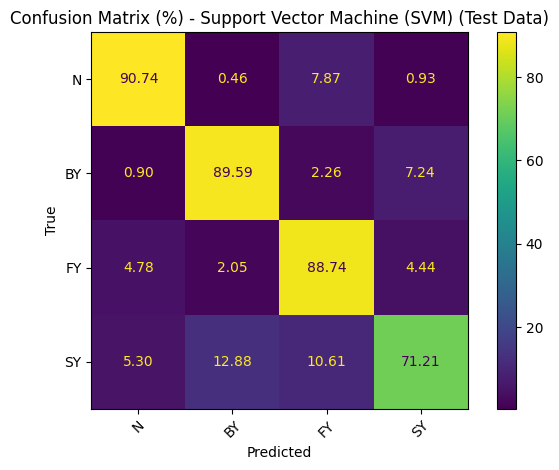

Index of experiment: 1
Experiment #: [10]
(2871, 216)

--- Fold 1 ---
Classification Report (Fold 1):
              precision    recall  f1-score   support

           N       0.84      0.88      0.86       151
          BY       0.85      0.87      0.86       155
          FY       0.80      0.83      0.81       205
          SY       0.71      0.54      0.62        92

    accuracy                           0.81       603
   macro avg       0.80      0.78      0.79       603
weighted avg       0.81      0.81      0.81       603


--- Fold 2 ---
Classification Report (Fold 2):
              precision    recall  f1-score   support

           N       0.84      0.91      0.88       151
          BY       0.82      0.91      0.87       155
          FY       0.84      0.81      0.82       205
          SY       0.79      0.60      0.68        92

    accuracy                           0.83       603
   macro avg       0.82      0.81      0.81       603
weighted avg       0.83      0.83  

<Figure size 1200x1000 with 0 Axes>

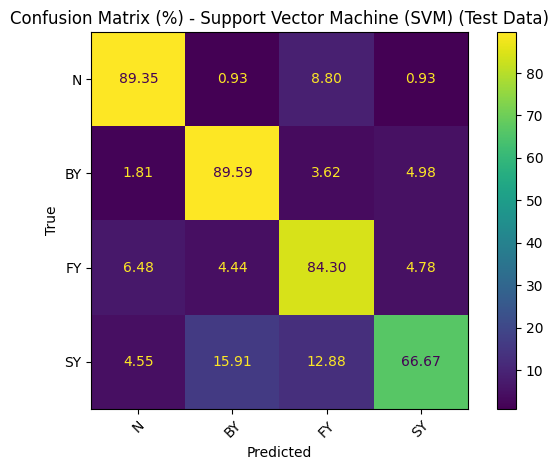

Index of experiment: 2
Experiment #: [2, 10]
(2871, 432)

--- Fold 1 ---
Classification Report (Fold 1):
              precision    recall  f1-score   support

           N       0.88      0.91      0.90       151
          BY       0.86      0.91      0.88       155
          FY       0.89      0.90      0.90       205
          SY       0.76      0.64      0.69        92

    accuracy                           0.86       603
   macro avg       0.85      0.84      0.84       603
weighted avg       0.86      0.86      0.86       603


--- Fold 2 ---
Classification Report (Fold 2):
              precision    recall  f1-score   support

           N       0.86      0.92      0.89       151
          BY       0.90      0.94      0.92       155
          FY       0.89      0.89      0.89       205
          SY       0.89      0.73      0.80        92

    accuracy                           0.89       603
   macro avg       0.89      0.87      0.88       603
weighted avg       0.89      0.8

<Figure size 1200x1000 with 0 Axes>

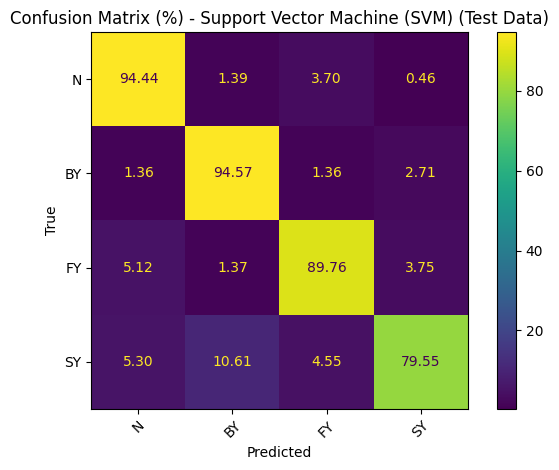

Index of experiment: 3
Experiment #: [12]
(2871, 216)

--- Fold 1 ---
Classification Report (Fold 1):
              precision    recall  f1-score   support

           N       0.86      0.86      0.86       151
          BY       0.72      0.71      0.71       155
          FY       0.87      0.87      0.87       205
          SY       0.60      0.61      0.61        92

    accuracy                           0.79       603
   macro avg       0.76      0.76      0.76       603
weighted avg       0.79      0.79      0.79       603


--- Fold 2 ---
Classification Report (Fold 2):
              precision    recall  f1-score   support

           N       0.77      0.83      0.80       151
          BY       0.72      0.72      0.72       155
          FY       0.82      0.81      0.82       205
          SY       0.62      0.54      0.58        92

    accuracy                           0.75       603
   macro avg       0.73      0.73      0.73       603
weighted avg       0.75      0.75  

<Figure size 1200x1000 with 0 Axes>

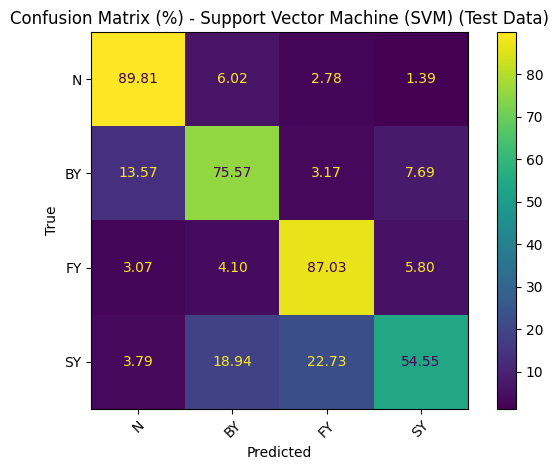

Index of experiment: 4
Experiment #: [2, 12]
(2871, 432)

--- Fold 1 ---
Classification Report (Fold 1):
              precision    recall  f1-score   support

           N       0.89      0.95      0.92       151
          BY       0.89      0.91      0.90       155
          FY       0.94      0.94      0.94       205
          SY       0.85      0.73      0.78        92

    accuracy                           0.90       603
   macro avg       0.89      0.88      0.88       603
weighted avg       0.90      0.90      0.90       603


--- Fold 2 ---
Classification Report (Fold 2):
              precision    recall  f1-score   support

           N       0.91      0.92      0.92       151
          BY       0.93      0.90      0.92       155
          FY       0.87      0.92      0.89       205
          SY       0.82      0.75      0.78        92

    accuracy                           0.89       603
   macro avg       0.88      0.87      0.88       603
weighted avg       0.89      0.8

<Figure size 1200x1000 with 0 Axes>

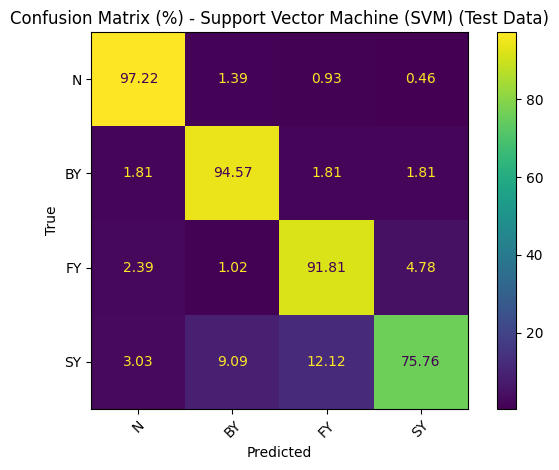

Index of experiment: 5
Experiment #: [10, 12]
(2871, 432)

--- Fold 1 ---
Classification Report (Fold 1):
              precision    recall  f1-score   support

           N       0.95      0.94      0.94       151
          BY       0.87      0.90      0.89       155
          FY       0.91      0.93      0.92       205
          SY       0.76      0.70      0.73        92

    accuracy                           0.89       603
   macro avg       0.87      0.87      0.87       603
weighted avg       0.89      0.89      0.89       603


--- Fold 2 ---
Classification Report (Fold 2):
              precision    recall  f1-score   support

           N       0.90      0.95      0.92       151
          BY       0.88      0.92      0.90       155
          FY       0.91      0.90      0.90       205
          SY       0.80      0.70      0.74        92

    accuracy                           0.88       603
   macro avg       0.87      0.86      0.87       603
weighted avg       0.88      0.

<Figure size 1200x1000 with 0 Axes>

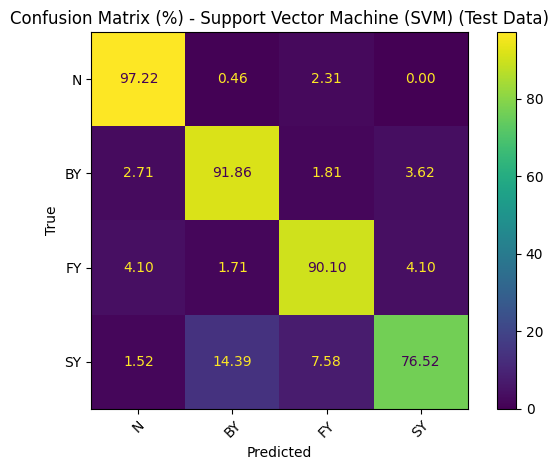

Index of experiment: 6
Experiment #: [2, 10, 12]
(2871, 648)

--- Fold 1 ---
Classification Report (Fold 1):
              precision    recall  f1-score   support

           N       0.92      0.96      0.94       151
          BY       0.90      0.91      0.91       155
          FY       0.92      0.94      0.93       205
          SY       0.83      0.73      0.77        92

    accuracy                           0.90       603
   macro avg       0.89      0.88      0.89       603
weighted avg       0.90      0.90      0.90       603


--- Fold 2 ---
Classification Report (Fold 2):
              precision    recall  f1-score   support

           N       0.89      0.93      0.91       151
          BY       0.91      0.94      0.92       155
          FY       0.91      0.92      0.92       205
          SY       0.89      0.76      0.82        92

    accuracy                           0.90       603
   macro avg       0.90      0.89      0.89       603
weighted avg       0.90     

<Figure size 1200x1000 with 0 Axes>

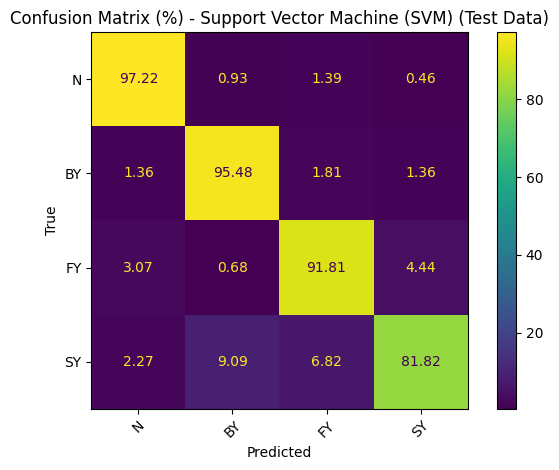

In [ ]:
# Define column names for each sensor and channel
accelerometer_Head = ['Segment Acceleration_Head x',	'Segment Acceleration_Head y',	'Segment Acceleration_Head z']
accelerometer_Pelvis = ['Segment Acceleration_Pelvis x', 'Segment Acceleration_Pelvis y', 'Segment Acceleration_Pelvis z']
accelerometer_Left_Shoulder = ['Segment Acceleration_Left Shoulder x', 'Segment Acceleration_Left Shoulder y', 'Segment Acceleration_Left Shoulder z']
accelerometer_Right_Shoulder = ['Segment Acceleration_Right Shoulder x', 'Segment Acceleration_Right Shoulder y', 'Segment Acceleration_Right Shoulder z']
accelerometer_Left_Forearm = ['Segment Acceleration_Left Forearm x', 'Segment Acceleration_Left Forearm y', 'Segment Acceleration_Left Forearm z']
accelerometer_Right_Forearm = ['Segment Acceleration_Right Forearm x',	'Segment Acceleration_Right Forearm y',	'Segment Acceleration_Right Forearm z']
accelerometer_Right_Upper_Arm = ['Segment Acceleration_Right Upper Arm x',	'Segment Acceleration_Right Upper Arm y',	'Segment Acceleration_Right Upper Arm z']
accelerometer_Left_Upper_Arm = ['Segment Acceleration_Left Upper Arm x',	'Segment Acceleration_Left Upper Arm y',	'Segment Acceleration_Left Upper Arm z']
accelerometer_Right_Upper_Leg = ['Segment Acceleration_Right Upper Leg x',	'Segment Acceleration_Right Upper Leg y',	'Segment Acceleration_Right Upper Leg z']
accelerometer_Left_Upper_Leg = ['Segment Acceleration_Left Upper Leg x',	'Segment Acceleration_Left Upper Leg y',	'Segment Acceleration_Left Upper Leg z']
accelerometer_Left_Lower_Leg = ['Segment Acceleration_Left Lower Leg x',	'Segment Acceleration_Left Lower Leg y', 'Segment Acceleration_Left Lower Leg z']
accelerometer_Right_Lower_Leg = ['Segment Acceleration_Right Lower Leg x',	'Segment Acceleration_Right Lower Leg y',	'Segment Acceleration_Right Lower Leg z']

Velocity_Pelvis = ['Segment Angular Velocity_Pelvis x',	'Segment Angular Velocity_Pelvis y',	'Segment Angular Velocity_Pelvis z']
Velocity_Head = ['Segment Angular Velocity_Head x',	'Segment Angular Velocity_Head y',	'Segment Angular Velocity_Head z']
Velocity_Right_Shoulder = ['Segment Angular Velocity_Right Shoulder x',	'Segment Angular Velocity_Right Shoulder y',	'Segment Angular Velocity_Right Shoulder z']
Velocity_Left_Shoulder = ['Segment Angular Velocity_Left Shoulder x',	'Segment Angular Velocity_Left Shoulder y',	'Segment Angular Velocity_Left Shoulder z']
Velocity_Right_Forearm = ['Segment Angular Velocity_Right Forearm x',	'Segment Angular Velocity_Right Forearm y',	'Segment Angular Velocity_Right Forearm z']
Velocity_Left_Forearm = ['Segment Angular Velocity_Left Forearm x',	'Segment Angular Velocity_Left Forearm y',	'Segment Angular Velocity_Left Forearm z']
Velocity_Right_Upper_Arm = ['Segment Angular Velocity_Right Upper Arm x',	'Segment Angular Velocity_Right Upper Arm y',	'Segment Angular Velocity_Right Upper Arm z']
Velocity_Left_Upper_Arm = ['Segment Angular Velocity_Left Upper Arm x',	'Segment Angular Velocity_Left Upper Arm y',	'Segment Angular Velocity_Left Upper Arm z']
Velocity_Right_Upper_Leg = ['Segment Angular Velocity_Right Upper Leg x',	'Segment Angular Velocity_Right Upper Leg y',	'Segment Angular Velocity_Right Upper Leg z']
Velocity_Right_Lower_Leg = ['Segment Angular Velocity_Right Lower Leg x',	'Segment Angular Velocity_Right Lower Leg y',	'Segment Angular Velocity_Right Lower Leg z']
Velocity_Left_Upper_Leg = ['Segment Angular Velocity_Left Upper Leg x',	'Segment Angular Velocity_Left Upper Leg y',	'Segment Angular Velocity_Left Upper Leg z']
Velocity_Left_Lower_Leg = ['Segment Angular Velocity_Left Lower Leg x',	'Segment Angular Velocity_Left Lower Leg y',	'Segment Angular Velocity_Left Lower Leg z']

Field_Pelvis = ['Sensor Magnetic Field_Pelvis x',	'Sensor Magnetic Field_Pelvis y',	'Sensor Magnetic Field_Pelvis z']
Field_Head = ['Sensor Magnetic Field_Head x',	'Sensor Magnetic Field_Head y',	'Sensor Magnetic Field_Head z']
Field_Right_Shoulder = ['Sensor Magnetic Field_Right Shoulder x',	'Sensor Magnetic Field_Right Shoulder y',	'Sensor Magnetic Field_Right Shoulder z']
Field_Right_Upper_Arm = ['Sensor Magnetic Field_Right Upper Arm x',	'Sensor Magnetic Field_Right Upper Arm y',	'Sensor Magnetic Field_Right Upper Arm z']
Field_Right_Forearm = ['Sensor Magnetic Field_Right Forearm x',	'Sensor Magnetic Field_Right Forearm y',	'Sensor Magnetic Field_Right Forearm z']
Field_Left_Shoulder = ['Sensor Magnetic Field_Left Shoulder x',	'Sensor Magnetic Field_Left Shoulder y',	'Sensor Magnetic Field_Left Shoulder z']
Field_Left_Upper_Arm = ['Sensor Magnetic Field_Left Upper Arm x',	'Sensor Magnetic Field_Left Upper Arm y',	'Sensor Magnetic Field_Left Upper Arm z']
Field_Left_Forearm = ['Sensor Magnetic Field_Left Forearm x',	'Sensor Magnetic Field_Left Forearm y',	'Sensor Magnetic Field_Left Forearm z']
Field_Right_Upper_Leg = ['Sensor Magnetic Field_Right Upper Leg x',	'Sensor Magnetic Field_Right Upper Leg y',	'Sensor Magnetic Field_Right Upper Leg z']
Field_Right_Lower_Leg = ['Sensor Magnetic Field_Right Lower Leg x',	'Sensor Magnetic Field_Right Lower Leg y',	'Sensor Magnetic Field_Right Lower Leg z']
Field_Left_Upper_Leg = ['Sensor Magnetic Field_Left Upper Leg x',	'Sensor Magnetic Field_Left Upper Leg y',	'Sensor Magnetic Field_Left Upper Leg z']	
Field_Left_Lower_Leg = ['Sensor Magnetic Field_Left Lower Leg x',	'Sensor Magnetic Field_Left Lower Leg y',	'Sensor Magnetic Field_Left Lower Leg z']

data_path = "G:/nia_20231103/nia_20231103/csv_files/"
import pandas as pd
appended_df = dict()
indexs = 0
for sensors_index in [
    [accelerometer_Pelvis, Velocity_Pelvis, Field_Pelvis],
    [accelerometer_Left_Upper_Leg, Velocity_Left_Upper_Leg, Field_Left_Upper_Leg],
    [accelerometer_Pelvis, Velocity_Pelvis, Field_Pelvis, accelerometer_Left_Upper_Leg, Velocity_Left_Upper_Leg, Field_Left_Upper_Leg],
    [accelerometer_Right_Lower_Leg, Velocity_Right_Lower_Leg, Field_Right_Lower_Leg],
    [accelerometer_Pelvis, Velocity_Pelvis, Field_Pelvis, accelerometer_Right_Lower_Leg, Velocity_Right_Lower_Leg, Field_Right_Lower_Leg],
    [accelerometer_Left_Upper_Leg, Velocity_Left_Upper_Leg, Field_Left_Upper_Leg, accelerometer_Right_Lower_Leg, Velocity_Right_Lower_Leg, Field_Right_Lower_Leg],
    [accelerometer_Pelvis, Velocity_Pelvis, Field_Pelvis, accelerometer_Left_Upper_Leg, Velocity_Left_Upper_Leg, Field_Left_Upper_Leg, accelerometer_Right_Lower_Leg, Velocity_Right_Lower_Leg, Field_Right_Lower_Leg]    
    ]:
    acc = []
    for i in range(0,len(sensors_index)-1, 3):
        if 'Segment Acceleration_Head x' in sensors_index[i]:
            acc.append(1)
        elif 'Segment Acceleration_Pelvis x' in sensors_index[i]:
            acc.append(2)
        elif 'Segment Acceleration_Left Shoulder x' in sensors_index[i]:
            acc.append(3)
        elif 'Segment Acceleration_Right Shoulder x' in sensors_index[i]:
            acc.append(4)
        elif 'Segment Acceleration_Left Forearm x' in sensors_index[i]:
            acc.append(5)
        elif 'Segment Acceleration_Right Forearm x' in sensors_index[i]:
            acc.append(6)
        elif 'Segment Acceleration_Right Upper Arm x' in sensors_index[i]:
            acc.append(7)
        elif 'Segment Acceleration_Left Upper Arm x' in sensors_index[i]:
            acc.append(8)
        elif 'Segment Acceleration_Right Upper Leg x' in sensors_index[i]:
            acc.append(9)
        elif 'Segment Acceleration_Left Upper Leg x' in sensors_index[i]:
            acc.append(10)
        elif 'Segment Acceleration_Left Lower Leg x' in sensors_index[i]:
            acc.append(11)
        elif 'Segment Acceleration_Right Lower Leg x' in sensors_index[i]:
            acc.append(12)
    print(f'Index of experiment: {indexs}')
    X1, y = load_data(data_path, sensors_index)
    print(f'Experiment #: {acc}')
    sampling_rate = 60  # Hz data, y1
    # Calculate time-domain features
    time_features = time_domain_features(X1)
    # Calculate frequency-domain features
    frequency_features = frequency_domain_features(X1)
    # Concatenate time-domain and frequency-domain features
    X_features = np.concatenate((time_features, frequency_features), axis=1)
    print(X_features.shape)
    # print(f'Experiment #: {indexs} and repeat {i}')
    appended_df[f'{indexs}'] = performance_v1(X_features, y, acc)
    indexs += 1

In [9]:
import datetime
import numpy as np
import pandas as pd

# Timestamp for file saving
now = datetime.datetime.now().strftime("%Y%m%d%H%M")

# Flatten the nested dictionary from your experiment results
flat_data = {}
for key, value in appended_df.items():
    flat_data[f'{key}'] = value

# Convert to DataFrame
df = pd.DataFrame.from_dict(flat_data, orient='index').transpose()
data = df.T.copy()

# Convert list columns to NumPy arrays
for col in ['accuracies', 'precisions', 'recalls', 'f1_scores', 'training_times']:
    data[col] = [np.array(item) for item in data[col]]

# ✅ Ensure all rows have the same length for the metrics to be exploded
consistent_rows = (
    data['accuracies'].apply(len) == data['precisions'].apply(len)) & \
    (data['accuracies'].apply(len) == data['recalls'].apply(len)) & \
    (data['accuracies'].apply(len) == data['f1_scores'].apply(len)) & \
    (data['accuracies'].apply(len) == data['training_times'].apply(len))

# Filter to only consistent rows
data_clean = data[consistent_rows].copy()

# ✅ Explode columns
df_exploded = data_clean.explode(['accuracies', 'precisions', 'recalls', 'f1_scores', 'training_times']).reset_index(drop=True)

# Add combination index
df_exploded['Combination'] = np.repeat(np.arange(len(data)), 10)

# Save to CSV
output_name = f'comparison_of_Lower_SVM_sensor_position_Multi_V1_{now}.csv'
df_exploded.to_csv(output_name, index=False)

# Show preview
print(f"[✅] Results saved to: {output_name}")
print(df_exploded.head())


[✅] Results saved to: comparison_of_Lower_SVM_sensor_position_Multi_V1_202504141156.csv
  accuracies precisions   recalls f1_scores mean_accuracy  std_dev  \
0   0.840796   0.839207  0.840796  0.839214       0.83665  0.01366   
1   0.865672   0.865152  0.865672  0.865059       0.83665  0.01366   
2   0.834163   0.831966  0.834163  0.831579       0.83665  0.01366   
3   0.842454   0.838902  0.842454  0.839661       0.83665  0.01366   
4   0.812604    0.81184  0.812604  0.811096       0.83665  0.01366   

  training_times         testing_times    places  Combination  
0       0.085525  [0.1186361312866211]  0.867749            0  
1       0.105218  [0.1186361312866211]  0.867749            0  
2       0.081582  [0.1186361312866211]  0.867749            0  
3       0.088476  [0.1186361312866211]  0.867749            0  
4       0.087222  [0.1186361312866211]  0.867749            0  
